# ALFF-based classification (project under Dr./Prof. Bindya)

Loads pre-extracted Amplitude of Low-Frequency Fluctuation (ALFF) features
from a resting-state fMRI dataset (`Alff_features_WCL.mat`, loaded from
Google Drive, not committed to this repo) and benchmarks several classical
classifiers (SVM, Random Forest, Naive Bayes variants, MLP, a small dense
network) on a binary classification task.

**Note on the data**: the feature matrix and any subject-level data are
kept out of this repository (see `.gitignore`) since they may be
identifiable clinical data — only the analysis code is version-controlled.

See the limitations note at the end of the notebook before treating the
reported metrics as evidence of a working classifier.

In [ ]:
from scipy.io import loadmat

# Replace 'your_file.mat' with the name of your file
mat_data = loadmat('/content/drive/MyDrive/Alff_features_WCL.mat')

# Print the keys of the loaded data
print(mat_data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'Features'])


In [ ]:
# Example: Accessing a specific variable
variable_data = mat_data['Features']
print(variable_data)

[[0.23944157 0.27658004 0.25855392 ... 0.         0.         1.        ]
 [0.35965949 0.24415201 0.29869235 ... 0.         0.         1.        ]
 [0.4229317  0.33445501 0.50549179 ... 0.         0.         1.        ]
 ...
 [4.92465591 4.25830317 3.92107224 ... 0.         0.         2.        ]
 [3.34531522 0.         0.         ... 0.         0.         2.        ]
 [3.29667854 2.4626143  2.63413262 ... 0.         0.         2.        ]]


In [ ]:
print(mat_data['__header__'])
print(mat_data['__version__'])
print(mat_data['__globals__'])


b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Sat Nov 23 17:48:32 2024'
1.0
[]


In [ ]:
features = mat_data['Features']  # Extract the array stored in 'Features'
print("Shape of Features:", features.shape)
print("Preview of Features:\n", features[:5])

Shape of Features: (2380, 47637)
Preview of Features:
 [[0.23944157 0.27658004 0.25855392 ... 0.         0.         1.        ]
 [0.35965949 0.24415201 0.29869235 ... 0.         0.         1.        ]
 [0.4229317  0.33445501 0.50549179 ... 0.         0.         1.        ]
 [0.48387605 0.35210237 0.35542113 ... 0.         0.         1.        ]
 [0.59121156 0.30568269 0.48902503 ... 0.         0.         1.        ]]


In [ ]:
print("Shape of Features:", features.shape)
import numpy as np

# Preview the last few rows and the last column
print("First 5 rows of Features:\n", features[:5])  # View some rows of the entire dataset
print("Last column (potential labels):\n", features[:5, -1])  # View the last column

# Check for unique values in the last column
unique_last_column = np.unique(features[:, -1])
print("Unique values in the last column:", unique_last_column)

# Check statistical properties of the last column
print("Mean of last column:", np.mean(features[:, -1]))
print("Standard deviation of last column:", np.std(features[:, -1]))

Shape of Features: (2380, 47637)
First 5 rows of Features:
 [[0.23944157 0.27658004 0.25855392 ... 0.         0.         1.        ]
 [0.35965949 0.24415201 0.29869235 ... 0.         0.         1.        ]
 [0.4229317  0.33445501 0.50549179 ... 0.         0.         1.        ]
 [0.48387605 0.35210237 0.35542113 ... 0.         0.         1.        ]
 [0.59121156 0.30568269 0.48902503 ... 0.         0.         1.        ]]
Last column (potential labels):
 [1. 1. 1. 1. 1.]
Unique values in the last column: [1. 2.]
Mean of last column: 1.4638655462184873
Standard deviation of last column: 0.49869259193406085


In [ ]:
y = features[:, -1]  # Extract the last column as labels
y = (y - 1).astype(int)  # Convert [1.0, 2.0] -> [0, 1]
print("Labels after transformation:", np.unique(y))  # Should print [0, 1]


Labels after transformation: [0 1]


In [ ]:
X = features[:, :-1]  # Exclude the last column
print("Shape of features:", X.shape)  # Verify shape


Shape of features: (2380, 47636)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (1904, 47636) (1904,)
Testing set shape: (476, 47636) (476,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.4891 - loss: 8.2587 - val_accuracy: 0.5483 - val_loss: 4.4708
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.5940 - loss: 3.2325 - val_accuracy: 0.4958 - val_loss: 5.8667
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.6516 - loss: 2.9730 - val_accuracy: 0.5756 - val_loss: 1.5800
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.7462 - loss: 0.9893 - val_accuracy: 0.5840 - val_loss: 1.5614
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.7600 - loss: 0.9412 - val_accuracy: 0.5042 - val_loss: 2.1258
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.8621 - loss: 0.4689 - val_accuracy: 0.5042 - val_loss: 2.7206
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.8233 - loss: 0.6866 - val_accuracy: 0.5630 - val_loss: 1.4447
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9274 - loss: 0.4798 - val_accuracy: 0.53

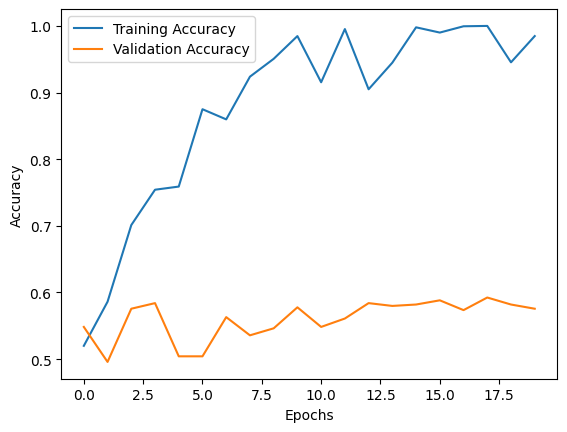

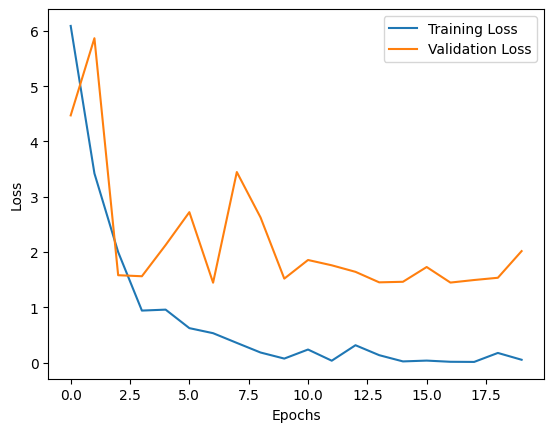

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
import numpy as np
import joblib
from scipy.io import loadmat
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, Binarizer, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load .mat file
mat_data = loadmat('/content/drive/MyDrive/Alff_features_WCL.mat')

# Extract features and labels
features = mat_data['Features']
X = features[:, :-1]
y = (features[:, -1] - 1).astype(int)  # Convert [1,2] → [0,1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

### 1️⃣ Feature Selection with PCA
pca = PCA(n_components=200)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
joblib.dump(pca, 'pca.pkl')

### 2️⃣ Feature Selection with SelectKBest
k = 500
selector = SelectKBest(score_func=f_classif, k=k)
X_train_kbest = selector.fit_transform(X_train, y_train)
X_test_kbest = selector.transform(X_test)
joblib.dump(selector, 'selectkbest.pkl')

### 3️⃣ Preprocessing for BernoulliNB
binarizer = Binarizer(threshold=0.0)
X_train_bin = binarizer.fit_transform(X_train_kbest)
X_test_bin = binarizer.transform(X_test_kbest)
joblib.dump(binarizer, 'binarizer.pkl')

### 4️⃣ Preprocessing for MultinomialNB
minmax_scaler = MinMaxScaler()
X_train_mnb = minmax_scaler.fit_transform(X_train_kbest)
X_test_mnb = minmax_scaler.transform(X_test_kbest)
joblib.dump(minmax_scaler, 'minmax_scaler.pkl')

### 5️⃣ Train & Tune BernoulliNB
bnb_param_grid = {'alpha': np.logspace(-3, 1, 5)}
bnb_grid = GridSearchCV(BernoulliNB(), bnb_param_grid, cv=3, n_jobs=-1)
bnb_grid.fit(X_train_bin, y_train)
print("Best BernoulliNB Parameters:", bnb_grid.best_params_)

bnb_model = BernoulliNB(**bnb_grid.best_params_)
bnb_model.fit(X_train_bin, y_train)
joblib.dump(bnb_model, 'bernoulli_nb_optimized.pkl')

### 6️⃣ Train & Tune MultinomialNB
mnb_param_grid = {'alpha': np.logspace(-3, 1, 5)}
mnb_grid = GridSearchCV(MultinomialNB(), mnb_param_grid, cv=3, n_jobs=-1)
mnb_grid.fit(X_train_mnb, y_train)
print("Best MultinomialNB Parameters:", mnb_grid.best_params_)

mnb_model = MultinomialNB(**mnb_grid.best_params_)
mnb_model.fit(X_train_mnb, y_train)
joblib.dump(mnb_model, 'multinomial_nb_optimized.pkl')

### 7️⃣ Train SVM (RBF kernel)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_kbest, y_train)
joblib.dump(svm_model, 'svm_model.pkl')

### 8️⃣ Evaluate BernoulliNB
y_pred_bnb = bnb_model.predict(X_test_bin)
print("BernoulliNB Accuracy:", accuracy_score(y_test, y_pred_bnb))
print("BernoulliNB Classification Report:\n", classification_report(y_test, y_pred_bnb))

### 9️⃣ Evaluate MultinomialNB
y_pred_mnb = mnb_model.predict(X_test_mnb)
print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("MultinomialNB Classification Report:\n", classification_report(y_test, y_pred_mnb))

### 🔟 Evaluate SVM
y_pred_svm = svm_model.predict(X_test_kbest)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

### 1️⃣ Train & Save Random Forest (No Scaling)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # No special preprocessing
joblib.dump(rf_model, 'random_forest.pkl')

### 2️⃣ Train & Save GaussianNB (StandardScaler)
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)  # Uses StandardScaler
joblib.dump(gnb_model, 'gaussian_nb.pkl')

### 3️⃣ Train & Save MLPClassifier (StandardScaler)
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)  # Uses StandardScaler
joblib.dump(mlp_model, 'mlp_classifier.pkl')

### ✅ Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
joblib.dump(rf_model, 'random_forest.pkl')

### ✅ Evaluate GaussianNB
y_pred_gnb = gnb_model.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("GaussianNB Classification Report:\n", classification_report(y_test, y_pred_gnb))

### ✅ Evaluate MLPClassifier
y_pred_mlp = mlp_model.predict(X_test)
print("MLPClassifier Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("MLPClassifier Classification Report:\n", classification_report(y_test, y_pred_mlp))



/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [   45    61    65 ... 47633 47634 47635] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best BernoulliNB Parameters: {'alpha': np.float64(10.0)}
Best MultinomialNB Parameters: {'alpha': np.float64(0.001)}
BernoulliNB Accuracy: 0.5273109243697479
BernoulliNB Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.64      0.59       255
           1       0.49      0.40      0.44       221

    accuracy                           0.53       476
   macro avg       0.52      0.52      0.52       476
weighted avg       0.52      0.53      0.52       476

MultinomialNB Accuracy: 0.5378151260504201
MultinomialNB Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.98      0.70       255
           1       0.56      0.02      0.04       221

    accuracy                           0.54       476
   macro avg       0.55      0.50      0.37       476
weighted avg       0.55      0.54      0.39       476

SVM Accuracy: 0.569327731092437
SVM Classification Report:
            

In [ ]:
# Load models
scaler = joblib.load('scaler.pkl')
pca = joblib.load('pca.pkl')
selector = joblib.load('selectkbest.pkl')
svm_model = joblib.load('svm_model.pkl')
rf_model = joblib.load('random_forest.pkl')
binarizer = joblib.load('binarizer.pkl')
minmax_scaler = joblib.load('minmax_scaler.pkl')
bnb_model = joblib.load('bernoulli_nb_optimized.pkl')
mnb_model = joblib.load('multinomial_nb_optimized.pkl')

# Example new data (replace with real input)
new_data = np.random.rand(1, 47636)  # Simulating a new data point

# Apply preprocessing
new_data_scaled = scaler.transform(new_data)
new_data_kbest = selector.transform(new_data_scaled)

# BernoulliNB prediction
new_data_bin = binarizer.transform(new_data_kbest)
bnb_prediction = bnb_model.predict(new_data_bin)

# MultinomialNB prediction
new_data_mnb = minmax_scaler.transform(new_data_kbest)
mnb_prediction = mnb_model.predict(new_data_mnb)

print("BernoulliNB Prediction:", bnb_prediction)
print("MultinomialNB Prediction:", mnb_prediction)

# Load saved models


# Example new data (replace with real input)
new_data = np.random.rand(1, 47636)  # Simulating a new data point

# Scale new data
new_data_scaled = scaler.transform(new_data)


BernoulliNB Prediction: [0]
MultinomialNB Prediction: [0]


ValueError: X has 47636 features, but SVC is expecting 500 features as input.


🔹 SVM (SelectKBest + StandardScaler)
Accuracy      : 0.5315
Precision     : 0.4773
Recall        : 0.0950
Specificity   : 0.9098
F1 Score      : 0.1585
AUC Score     : 0.4671
              precision    recall  f1-score   support

           0       0.54      0.91      0.68       255
           1       0.48      0.10      0.16       221

    accuracy                           0.53       476
   macro avg       0.51      0.50      0.42       476
weighted avg       0.51      0.53      0.44       476


🔹 Random Forest (No Scaling)
Accuracy      : 0.5609
Precision     : 0.5400
Recall        : 0.3665
Specificity   : 0.7294
F1 Score      : 0.4367
AUC Score     : 0.5734
              precision    recall  f1-score   support

           0       0.57      0.73      0.64       255
           1       0.54      0.37      0.44       221

    accuracy                           0.56       476
   macro avg       0.56      0.55      0.54       476
weighted avg       0.56      0.56      0.55       476


🔹

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🔹 MLP (Neural Net, StandardScaler)
Accuracy      : 0.5504
Precision     : 0.5593
Recall        : 0.1493
Specificity   : 0.8980
F1 Score      : 0.2357
AUC Score     : 0.5912
              precision    recall  f1-score   support

           0       0.55      0.90      0.68       255
           1       0.56      0.15      0.24       221

    accuracy                           0.55       476
   macro avg       0.55      0.52      0.46       476
weighted avg       0.55      0.55      0.47       476



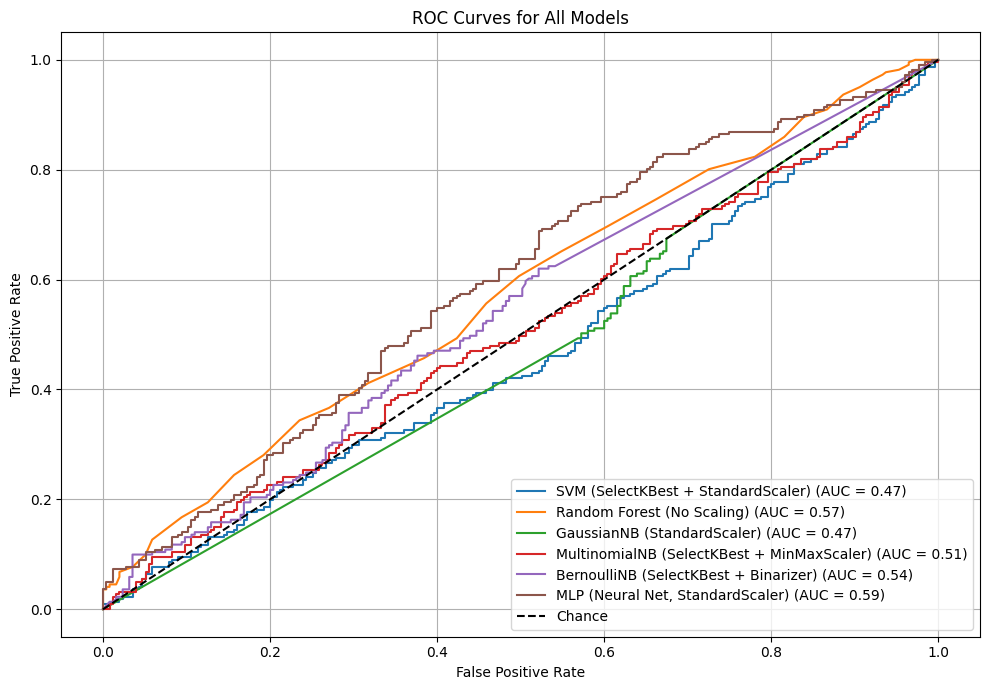


📊 Final Comparison Table:
                                            Accuracy  Precision  \
SVM (SelectKBest + StandardScaler)            0.5315     0.4773   
Random Forest (No Scaling)                    0.5609     0.5400   
GaussianNB (StandardScaler)                   0.4622     0.4319   
MultinomialNB (SelectKBest + MinMaxScaler)    0.5357     0.0000   
BernoulliNB (SelectKBest + Binarizer)         0.5441     0.5476   
MLP (Neural Net, StandardScaler)              0.5504     0.5593   

                                            Recall (Sensitivity)  Specificity  \
SVM (SelectKBest + StandardScaler)                        0.0950       0.9098   
Random Forest (No Scaling)                                0.3665       0.7294   
GaussianNB (StandardScaler)                               0.5023       0.4275   
MultinomialNB (SelectKBest + MinMaxScaler)                0.0000       1.0000   
BernoulliNB (SelectKBest + Binarizer)                     0.1041       0.9255   
MLP (Neural Net, 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, classification_report
)

# Load test features (already transformed during training)
X_test_scaled = joblib.load('scaler.pkl').transform(X_test)
X_test_kbest = joblib.load('selectkbest.pkl').transform(X_test_scaled)
X_test_bin = joblib.load('binarizer.pkl').transform(X_test_kbest)
X_test_mnb = joblib.load('minmax_scaler.pkl').transform(X_test_kbest)

# Load models
models = {
    "SVM (SelectKBest + StandardScaler)": joblib.load('svm_model.pkl'),
    "Random Forest (No Scaling)": joblib.load('random_forest.pkl'),
    "GaussianNB (StandardScaler)": joblib.load('gaussian_nb.pkl'),
    "MultinomialNB (SelectKBest + MinMaxScaler)": joblib.load('multinomial_nb_optimized.pkl'),
    "BernoulliNB (SelectKBest + Binarizer)": joblib.load('bernoulli_nb_optimized.pkl'),
    "MLP (Neural Net, StandardScaler)": joblib.load('mlp_classifier.pkl')
}

# Metric storage
metrics = {}
plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Pick the right features for each model
    if "SVM" in name or "GaussianNB" in name or "MLP" in name:
        X_test_model = X_test_scaled
        # For SVM specifically, we need the SelectKBest transformed data
        if "SVM" in name:
            X_test_model = X_test_kbest
    elif "Random Forest" in name:
        X_test_model = X_test
    elif "MultinomialNB" in name:
        X_test_model = X_test_mnb
    elif "BernoulliNB" in name:
        X_test_model = X_test_bin

    # Predict
    y_pred = model.predict(X_test_model)

    # Get probabilities for ROC AUC
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_model)[:, 1]
    else:
        y_probs = model.decision_function(X_test_model)
        y_probs = (y_probs - y_probs.min()) / (y_probs.max() - y_probs.min())  # normalize to [0, 1]

    # Confusion Matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_test, y_probs)

    metrics[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec,
        'Specificity': specificity,
        'F1 Score': f1,
        'AUC': auc
    }

    # Print detailed report
    print(f"\n🔹 {name}")
    print(f"Accuracy      : {acc:.4f}")
    print(f"Precision     : {prec:.4f}")
    print(f"Recall        : {rec:.4f}")
    print(f"Specificity   : {specificity:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print(f"AUC Score     : {auc:.4f}")
    print(classification_report(y_test, y_pred))

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

# Final ROC Curve Plot
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Tabular summary
df_metrics = pd.DataFrame(metrics).T
print("\n📊 Final Comparison Table:")
print(df_metrics.round(4))

## Limitations

With 47,636 ALFF features and roughly 2,380 subjects (a single 80/20
split), this is a severe *p* >> *n* setting. The accuracy/AUC values above
should be read against that backdrop:

- Values near 0.5 (chance) indicate the corresponding model is not
  extracting a reliable signal from these features with this amount of
  data and no dimensionality reduction/regularization tuned for it.
- A single train/test split is not sufficient evidence either way given
  the feature-to-sample ratio; nested or repeated k-fold cross-validation
  would give a more trustworthy estimate.
- Any strong training accuracy alongside weak validation/test accuracy
  (see the dense-network history above) is a sign of overfitting, not of
  the model having learned the task.

Next step before drawing conclusions from this notebook: repeat the
evaluation with nested cross-validation and report confidence intervals,
rather than a single split's point estimate.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
